# Quantum Teleportation Circuit

## The Reality of Quantum Teleportation

Despite what the name suggests, quantum teleportation isn't about beaming people across the galaxy like in *Star Trek*. It doesn't move matter; instead, it **transfers information**—specifically the exact quantum state of a particle—from one location to another using the principles of entanglement and classical communication.

---

### The Three Key Players

To understand the process, we usually look at three components:

1. **Alice:** The sender who has a particle (let’s say an electron or photon) in an unknown quantum state ($|\psi\rangle$).
2. **Bob:** The receiver who needs to recreate Alice's particle state.
3. **An Entangled Pair:** A pair of particles that are "linked" regardless of distance. Alice and Bob each take one particle from this pair.

---

### How the Process Works

Quantum teleportation follows a specific protocol that ensures the "no-cloning theorem" isn't violated (you can't create an identical copy of a quantum state without destroying the original).

#### 1. Entanglement (The "Bridge")

First, Alice and Bob share an entangled pair of particles. Because they are entangled, the state of Alice's entangled particle is mathematically tied to Bob's, even if he moves to the other side of the universe.

#### 2. The Bell State Measurement

Alice takes her unknown particle ($|\psi\rangle$) and performs a specific operation (a Bell State Measurement) on it alongside her half of the entangled pair.

* **The Catch:** This measurement "scrambles" the unknown particle. Alice no longer has the original state; she has destroyed it to extract information.

#### 3. Classical Communication

The result of Alice's measurement is two bits of ordinary, "classical" information (like 01 or 11). She sends these bits to Bob via traditional means—phone, email, or laser pulse.

> **Note:** Because this step relies on classical communication, quantum teleportation **cannot** happen faster than the speed of light.

#### 4. The Transformation

Once Bob receives the two bits, he knows exactly how his entangled particle is oriented relative to Alice’s original state. He performs a specific physical operation (a "unitary transformation") on his particle.

**The Result:** Bob’s particle becomes an exact replica of Alice’s original unknown particle ($|\psi\rangle$).

---

### Why is this important?

* **Quantum Computing:** It is the primary method for moving information between different parts of a quantum computer.
* **Quantum Internet:** It allows for the creation of ultra-secure communication networks where any attempt to "eavesdrop" would collapse the quantum state and alert the users.
* **Information vs. Matter:** It proves that in the quantum world, the "identity" of a particle is defined by its state (information) rather than the specific hunk of matter it’s made of.

---

To start the circuit, we first need to import necessary libraries to create quantum circuit.

In [1]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

We are creating a quantum circuit having 3 qubits. 1 qubit is used to create the quantum state that will be sent over entangled pair. Other 2 qubits will be used to create entangled pair.

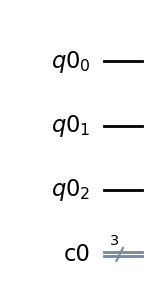

In [2]:
# Defining number of qubits and classical registers 
q_reg = QuantumRegister(3)
c_reg = ClassicalRegister(3)
q_ckt = QuantumCircuit(q_reg, c_reg)
q_ckt.draw(output="mpl")

We now prepare a qubit 1 in the mixed state of $|0\rangle$ and $|1\rangle$ using hadamard gate.

Qubit 1: $a|0\rangle + b|1\rangle$

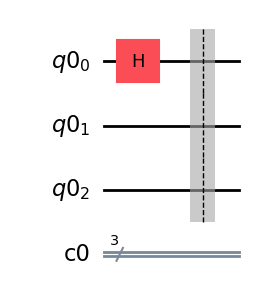

In [3]:
# state preparation
q_ckt.h(q_reg[0])
q_ckt.barrier()
q_ckt.draw(output="mpl")

To prepare a bell state, we will first use hadamard gate on qubit 2 to convert it into mixed state and then we will apply controlled not gate from qubit 2 to qubit 3. This will prepare a bell state - $|00\rangle + |11\rangle$ 

Bell states available for 2 qubits are - 

$$\Phi^+ = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

$$\Phi^- = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$$

$$\Psi^+ = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$$

$$\Psi^- = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$$

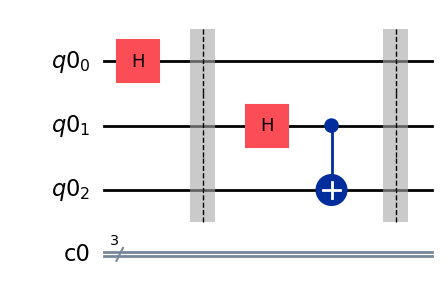

In [4]:
# Bell state preparation
q_ckt.h(q_reg[1])
q_ckt.cx(q_reg[1], q_reg[2])
q_ckt.barrier()
q_ckt.draw(output="mpl")

We have a qubit 1 - as the qubit that we want to transfer from Alice to the Bob. 

We applied hadamard on qubit 2 first to convert it into mixed state of $|0\rangle + |1\rangle$

qubit 2: $|0\rangle + |1\rangle$
qubit 3: $|0\rangle$

After applying controlled not on qubit 3, we have our bell state - $|00\rangle + |11\rangle$

State of all the qubits:

$$(a|0\rangle+ b|1\rangle) (|00\rangle + |11\rangle)$$

$$a|000\rangle + a|011\rangle + b|100\rangle + b|111\rangle$$

in this bell state, Qubit 2 belongs to Alice and Qubit 3 belongs to Bob. 

Now, Alice interacts her qubit, i.e. qubit 2 with the qubit 1, state of this qubit is what she wants to send to Bob. For interaction, we apply controlled not gate from qubit 1 to qubit 2, which is then followed by hadamard gate on qubit 1 to detangle it. 

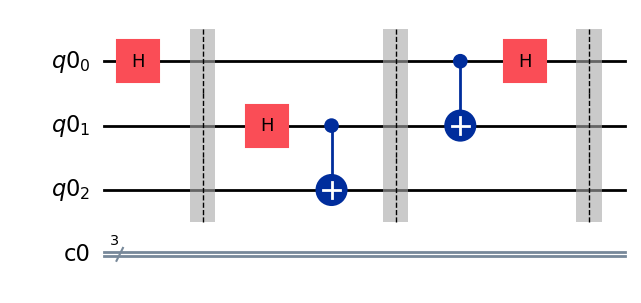

In [5]:
# Alice's Interaction
q_ckt.cx(q_reg[0], q_reg[1])
q_ckt.h(q_reg[0])
q_ckt.barrier()
q_ckt.draw(output="mpl")

This interaction created entanglement between qubit 1 and qubit 2. When controlled not gate was applied on qubit 2, state of qubit 1 and 2 created was $a|00\rangle + a|01\rangle + b|11\rangle + b|10\rangle$ 

Combining this with the qubit 3, we get the state as 

$a|000\rangle + a|011\rangle + b|110\rangle + b|101\rangle$ 

Now if we take out qubit 1, we get $a|0\rangle (|00\rangle + |11\rangle) + b|1\rangle (|10\rangle + |01\rangle)$

Now, we apply hadamard gate again to get the state

$a(|0\rangle + |1\rangle) (|00\rangle + |11\rangle) + b(|0\rangle - |1\rangle) (|10\rangle + |01\rangle)$

$a|000\rangle + a|011\rangle + a|100\rangle + a|111\rangle + b|010\rangle + b|001\rangle -b|110\rangle -b|101\rangle$

Re-arranging, we get, 

$a|000\rangle + a|011\rangle + b|010\rangle + b|001\rangle +  a|100\rangle + a|111\rangle -b|110\rangle -b|101\rangle$

$|0\rangle (a|00\rangle + a|11\rangle + b|10\rangle + b|01\rangle) + |1\rangle (a|00\rangle + a|11\rangle -b|10\rangle -b|01\rangle)$

$|0\rangle (a|00\rangle + b|01\rangle + a|11\rangle + b|10\rangle) + |1\rangle (a|00\rangle - b|01\rangle + a|11\rangle -b|10\rangle)$

$|0\rangle (|0\rangle (a|0\rangle + b|1\rangle) + |1\rangle (a|1\rangle + b|0\rangle)) + |1\rangle (|0\rangle (a|0\rangle - b|1\rangle) + |1\rangle (a|1\rangle -b|0\rangle))$

$|00\rangle (a|0\rangle + b|1\rangle) + |01\rangle (a|1\rangle + b|0\rangle) + |10\rangle (a|0\rangle - b|1\rangle) + |11\rangle (a|1\rangle -b|0\rangle)$

From the last equation above, we can understand the different states that can be achieved with the right measurement. So now Alice measures Qubits on her side. 

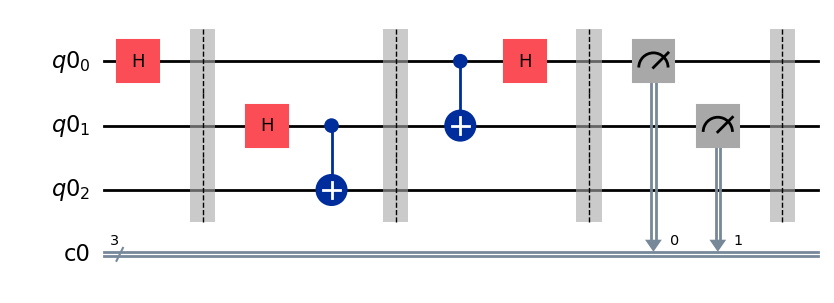

In [6]:
# Alice's measurement
q_ckt.measure(q_reg[0], c_reg[0])
q_ckt.measure(q_reg[1], c_reg[1])
q_ckt.barrier()
q_ckt.draw(output="mpl")

Once measured, output of the measured qubits is sent using classical channel to the Bob. Based on the result, he decides the operations he needs to perform on its qubits. Following table gives idea on operations Bob need to perform based on the bits received from the Alice.

| Alice's Bits (c1​,c0​) | Operation Bob needs to perform |
|---|---|
| 0 0 | Do Nothing (Identity I) |
| 0 1 | Apply X Gate (Bit Flip) |
| 1 0 | Apply Z Gate (Phase Flip) |
| 1 1 | Apply X then Z Gate (Bit + Phase Flip) |

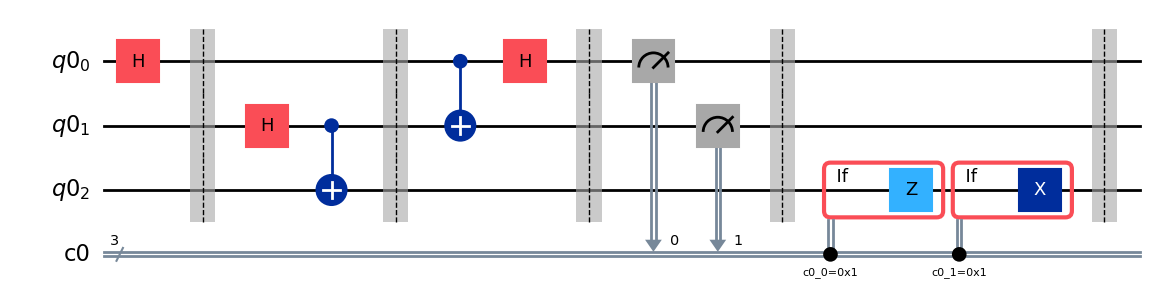

In [7]:
# Bob's operations 
with q_ckt.if_test((c_reg[0], 1)):
    q_ckt.z(q_reg[2])
with q_ckt.if_test((c_reg[1], 1)):
    q_ckt.x(q_reg[2])
q_ckt.barrier()
q_ckt.draw(output="mpl")

Bob corrects it's output to reflect the right state in the measurement. Now he measures his qubit.

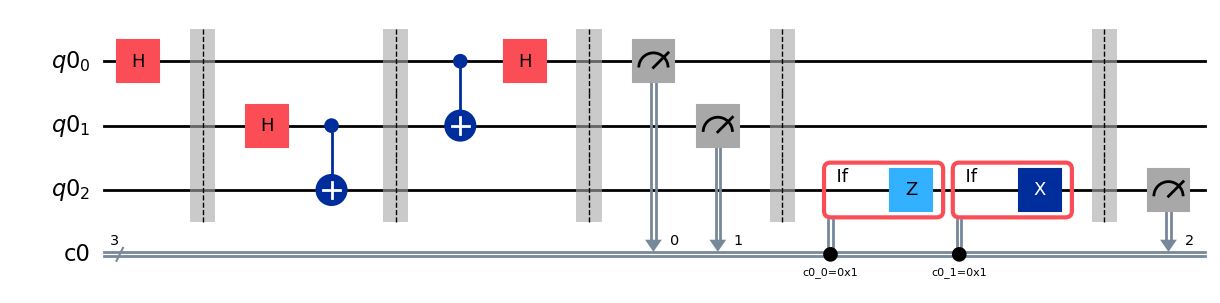

In [8]:
# Bob's measurement - Verification of state received
q_ckt.measure(q_reg[2], c_reg[2])
q_ckt.draw(output="mpl")

Whole quantum teleportation circuit is now ready. Now, We need to run the circuit on the simulator. 

We will use aer simulator. To use it, we will first have to import it. 

We are going to use transpile function to transpile the circuit on the simulator, so we will import that as well.

In [9]:
from qiskit_aer import AerSimulator
from qiskit import transpile

In [10]:
# initializing simulator and transpiling the circuit on the simulator
simulator = AerSimulator()
q_ckt = transpile(q_ckt, simulator)

We will run the circuit 1000 times on the simulator and get the results.

In [11]:
# Run and get memory
result = simulator.run(q_ckt, shots=1000, memory=True).result()
memory = result.get_memory(q_ckt)
print("Completed running circuit 1000 times!")

Completed running circuit 1000 times!


To view the results, we are going to use histogram.

In [12]:
# To plot the result
import matplotlib.pyplot as plt

In [13]:
r = []
for i in range(1000):
    r.append((int(result.get_memory(q_ckt)[i][2])))
print("Result of counts of qubit 2 - |0>:", r.count(0), " & |1>:", r.count(1))

Result of counts of qubit 2 - |0>: 467  & |1>: 533


(array([467., 533.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

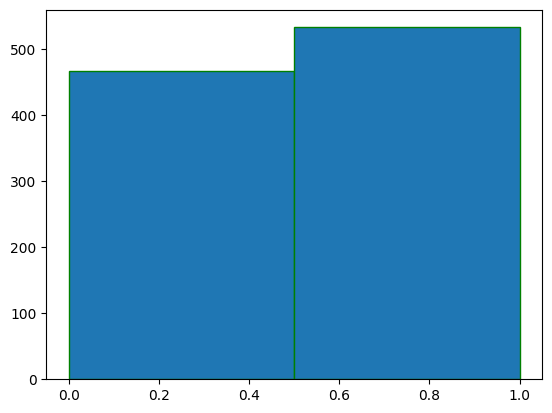

In [14]:
plt.hist(r, bins=2, edgecolor='g')

As we can see, from the above histogram, measurement of qubit 2 yields in the mixed state, i.e., measurement gives both the results nearly half - as we expect that to be since we prepared initial state using hadamard which means equal superposition of both the states. 

In [15]:
from qiskit.visualization import plot_histogram, plot_state_city

In [16]:
# Print the count
counts = result.get_counts(q_ckt)
print(counts)

{'001': 139, '000': 111, '010': 127, '111': 129, '011': 136, '110': 115, '100': 114, '101': 129}


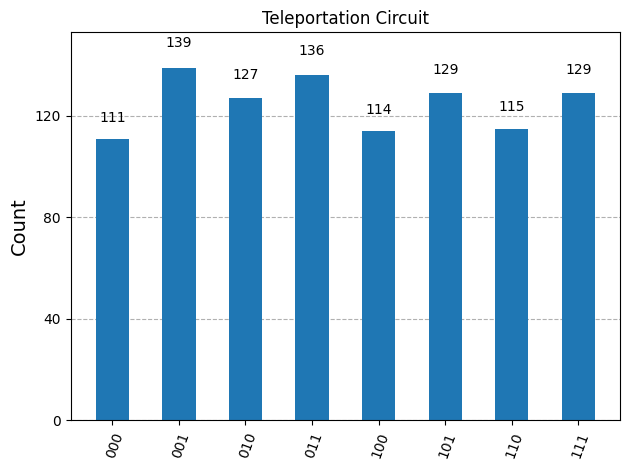

In [17]:
# plot histogram
plot_histogram(counts, title='Teleportation Circuit')

Above histogram gives all the states. If you look at the qubit 2 result - at the left most qubit, it yields in both 0 & 1, with almost equal probability.

You can try playing with the initial state preparation to understand the proper working of this protocol. 

## Result: 

Quantum Teleportation works but is not like the sci-fi teleportation. It cannot transfer the information at the speed of light, due to its need to transfer information classically. This need arises due to the very nature of the quantum particles, their collapse into one of the states.

-------